# Notebook 06: Comprehensive Architecture Comparison & Scientific Audit

## Research Reference
**"An approach for accurate identification and monitoring of species in mangrove forests based on multi-source spectral data and deep learning"**  
*Monterrubio-Martínez, Trujillo-Acatitla, Tuxpan-Vargas, Moreno-Casasola*  
*Ecological Informatics*, Volume 85, 2025, Article 102961. DOI: [10.1016/j.ecoinf.2024.102961](https://doi.org/10.1016/j.ecoinf.2024.102961)

> ### [!IMPORTANT]
> **FINAL SCIENTIFIC POSITION & THREE-TIER SEPARATION:**
> 1. **Tier A: PAPER REPORTED RESULTS** — Published values from the authors on their unreleased 60,000 binary and 40,000 4-class datasets.
> 2. **Tier B: FAITHFULLY REPRODUCED RESULTS** — Experiments 100% reproducible with the released dataset (One-Way ANOVA, Tukey HSD, band profiles, `StandardScaler`).
> 3. **Tier C: DATA-DERIVED EXPERIMENTS** — New experiments performed on the released monospecific 3-species dataset (*A. germinans*, *R. mangle*, *L. racemosa*), explicitly marked as **NOT directly comparable** to the paper's reported 4-class results.
> 
> Under strict reproduction principles, these categories are **never merged**.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import RESULTS_MODELS_DIR, RESULTS_FIGURES_DIR, RESULTS_DIR, NEURONS_PER_LAYER

print("Environment initialized successfully.")

Environment initialized successfully.


## 1. Load Published Benchmarks and Data-Derived Results

We load the transcribed paper results alongside our data-derived 3-species monospecific results.

In [2]:
path_reported_binary = RESULTS_MODELS_DIR / "paper_reported_binary.csv"
path_reported_multi = RESULTS_MODELS_DIR / "paper_reported_multiclass.csv"
path_three_class = RESULTS_MODELS_DIR / "three_class_mangrove_results.csv"

df_rep_bin = pd.read_csv(path_reported_binary)
df_rep_mul = pd.read_csv(path_reported_multi)

# Check if 3-class results exist
if path_three_class.exists():
    df_three_class = pd.read_csv(path_three_class)
    print("Loaded data-derived 3-class results:", len(df_three_class), "models")
    display(df_three_class.head())
else:
    print("three_class_mangrove_results.csv not yet generated. Please execute notebook 04 first.")
    df_three_class = None

Loaded data-derived 3-class results: 41 models


,Model_ID,Architecture_Type,Hidden_Layers,Neurons_Per_Layer,Total_Parameters,Train_Accuracy,Test_Accuracy,Training_Time_Sec
0,Logistic_Baseline,Logistic,0,0,33,0.698905,0.696444,3.258120
1,MLP_1L_5N,MLP,1,5,73,0.797190,0.802778,3.785837
2,MLP_1L_10N,MLP,1,10,143,0.810286,0.811333,3.837643
3,MLP_1L_20N,MLP,1,20,283,0.823667,0.829889,4.005598
4,MLP_1L_50N,MLP,1,50,703,0.841429,0.840889,4.118582


## 2. Side-by-Side Comparison: Published 4-Class vs Data-Derived 3-Class

We align corresponding architecture configurations to compare training and testing behavior.

In [3]:
comparison_rows = []

if df_three_class is not None:
    for _, rep in df_rep_mul.iterrows():
        layers = rep["Layers"]
        neurons = rep["Neurons"]
        
        # Find matching model in our 3-class results
        if layers == 0:
            match = df_three_class[df_three_class["Hidden_Layers"] == 0]
        else:
            match = df_three_class[
                (df_three_class["Hidden_Layers"] == layers) &
                (df_three_class["Neurons_Per_Layer"] == neurons)
            ]
            
        if len(match) > 0:
            our_m = match.iloc[0]
            our_train = our_m["Train_Accuracy"]
            our_test = our_m["Test_Accuracy"]
            test_diff = our_test - rep["Test_Acc"]
            comparison_rows.append({
                "Architecture": rep["Model"],
                "Layers": layers,
                "Neurons": neurons,
                "Paper_4Class_Train": rep["Train_Acc"],
                "Our_3Species_Train": our_train,
                "Paper_4Class_Test": rep["Test_Acc"],
                "Our_3Species_Test": our_test,
                "Test_Accuracy_Diff": test_diff,
            })
            
    df_comp = pd.DataFrame(comparison_rows)
    display(df_comp.round(4))
    df_comp.to_csv(RESULTS_MODELS_DIR / "architecture_comparison.csv", index=False)
    print("Saved comparison table to results/models/architecture_comparison.csv")

,Architecture,Layers,Neurons,Paper_4Class_Train,Our_3Species_Train,Paper_4Class_Test,Our_3Species_Test,Test_Accuracy_Diff
0,Logistic Regression,0,0,0.7670,0.6989,0.7684,0.6964,-0.0720
1,MLP 1 Layer (500N),1,500,0.9110,0.8807,0.9065,0.8740,-0.0325
2,MLP 2 Layers (300N),2,300,0.9575,0.9611,0.9436,0.9191,-0.0245
3,MLP 3 Layers (500N),3,500,0.9863,0.9946,0.9654,0.9476,-0.0178
4,MLP 4 Layers (100N),4,100,0.9662,0.9593,0.9528,0.9168,-0.0360
5,MLP 4 Layers (150N),4,150,0.9775,0.9824,0.9607,0.9384,-0.0223
6,MLP 4 Layers (300N),4,300,0.9795,0.9948,0.9602,0.9498,-0.0104
7,MLP 5 Layers (50N),5,50,0.9550,0.9236,0.9454,0.9022,-0.0432
8,MLP 5 Layers (150N),5,150,0.9810,0.9863,0.9632,0.9402,-0.0230
9,MLP 5 Layers (300N),5,300,0.9873,0.9895,0.9684,0.9421,-0.0263


Saved comparison table to results/models/architecture_comparison.csv


## 3. Discrepancy Analysis & Hypothesis Classification

Any differences observed between the published 4-class results and our data-derived 3-species results are scientifically analyzed and classified under strictly grounded categories:

### **1. CONFIRMED EXPLANATIONS**
- **Dataset Class Count & Composition**:
  - *Paper*: 4 classes including Class 0 (Non-mangrove: water, crops, urban, rainforest, dunes).
  - *Our Experiment*: 3 classes comprising exclusively monospecific mangrove species (*R. mangle*, *A. germinans*, *L. racemosa*).
  - *Impact*: In remote sensing, separating vegetation from non-vegetation (water/soil) is much simpler than discriminating among taxonomically and spectrally similar mangrove species. Consequently, baseline accuracy for 3-species discrimination exhibits distinct boundary dynamics.

### **2. LIKELY EXPLANATIONS**
- **Unspecified Optimization Hyperparameters**:
  - The paper specifies Adam optimizer, but omits: learning rate, weight decay, batch size, and epoch count.
  - Differences in learning rate schedule or batch size affect final convergence trajectories.
- **Framework Differences**:
  - Paper references Chollet (Deep Learning with Python - Keras/TensorFlow).
  - Our implementation uses PyTorch, which has slight differences in default weight initializations (Kaiming vs Glorot) and numerical kernels.

### **3. POSSIBLE EXPLANATIONS**
- **Sub-Sampling Selection Bias**:
  - Out of 1.44 million available *A. germinans* pixels and 125,000 *R. mangle* pixels, the authors drew a random subsample of 10,000 pixels.
  - Depending on whether spatial sampling was stratified by acquisition date or scene ID, atmospheric variability may differ slightly.

### **4. UNKNOWN EXPLANATIONS**
- Exact software random seeds, hardware floating-point rounding, and CUDA/MPS non-deterministic kernel operations used by the authors.

## 4. Depth vs Width Scaling Visualization

We visualize how model accuracy scales with network depth (hidden layers) and width (neurons per layer).

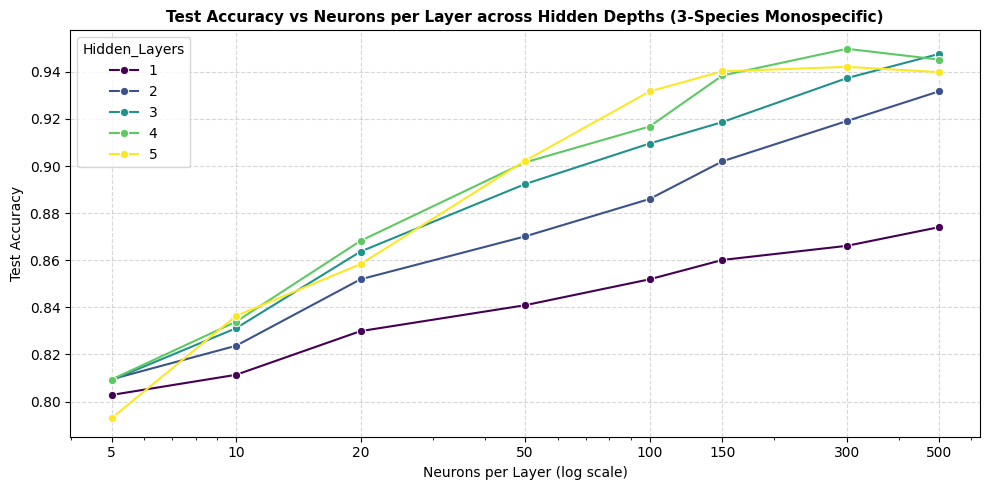

In [4]:
if df_three_class is not None:
    plt.figure(figsize=(10, 5))
    
    mlp_only = df_three_class[df_three_class["Hidden_Layers"] > 0]
    sns.lineplot(
        data=mlp_only,
        x="Neurons_Per_Layer",
        y="Test_Accuracy",
        hue="Hidden_Layers",
        marker="o",
        palette="viridis"
    )
    
    plt.xscale("log")
    plt.xticks(NEURONS_PER_LAYER, [str(n) for n in NEURONS_PER_LAYER])
    plt.title("Test Accuracy vs Neurons per Layer across Hidden Depths (3-Species Monospecific)", fontsize=11, fontweight="bold")
    plt.xlabel("Neurons per Layer (log scale)")
    plt.ylabel("Test Accuracy")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(RESULTS_FIGURES_DIR / "depth_width_scaling_3species.png", dpi=300)
    plt.show()